# Noise Robustness Analizi

Kritik görünürlük modeli: ρ_noisy = v·ρ + (1-v)·I/d

Kuantum değer: S = Σ⟨P_v⟩, maksimum = η_d(G)
Gürültülü değer: S_noisy = v·η_d + (1-v)·n/d
Klasik sınır: α(G)

Kritik görünürlük: v* = (α - n/d) / (η_d - n/d)
Kontextualite için v > v* gerekli.

In [4]:
import numpy as np

def critical_visibility(alpha, eta_d, n, d):
    """Kritik görünürlük: depolarizing noise modeli."""
    noise_val = n / d
    if eta_d <= alpha:
        return float('inf')  # kuantum avantajı yok
    return (alpha - noise_val) / (eta_d - noise_val)

def noise_tolerance(v_star):
    """Maksimum tolere edilebilir gürültü = 1 - v*"""
    return 1 - v_star

# Graflar ve değerleri
graphs = [
    # (isim,  n,  alpha, eta_d,          d,   not)
    ('C5 (KCBS)',      5, 2, 2.23607,  3, 'eta_3 = sqrt(5)'),
    ('C7',             7, 3, 3.31767,  3, 'eta_3 analitik'),
    ('Quad-C5 (d=3)',  8, 3, 3.23607,  3, 'eta_3 = 1+sqrt(5)'),
    ('Quad-C5 (d=4)',  8, 3, 3.46784,  4, 'eta_4 ~ theta'),
    ('Wagner (d=4)',   8, 3, 3.41421,  4, 'eta_4 ~ theta'),
]

print(f'{"Graf":<22} {"n":<4} {"α":<4} {"η_d":<8} {"d":<4} {"v*":<8} {"1-v* (gürültü tol.)":<22} {"Not"}')
print('-' * 95)

for name, n, alpha, eta_d, d, note in graphs:
    vs = critical_visibility(alpha, eta_d, n, d)
    nt = noise_tolerance(vs)
    print(f'{name:<22} {n:<4} {alpha:<4} {eta_d:<8.5f} {d:<4} {vs:<8.4f} {nt:<22.4f} {note}')

Graf                   n    α    η_d      d    v*       1-v* (gürültü tol.)    Not
-----------------------------------------------------------------------------------------------
C5 (KCBS)              5    2    2.23607  3    0.5854   0.4146                 eta_3 = sqrt(5)
C7                     7    3    3.31767  3    0.6773   0.3227                 eta_3 analitik
Quad-C5 (d=3)          8    3    3.23607  3    0.5854   0.4146                 eta_3 = 1+sqrt(5)
Quad-C5 (d=4)          8    3    3.46784  4    0.6813   0.3187                 eta_4 ~ theta
Wagner (d=4)           8    3    3.41421  4    0.7071   0.2929                 eta_4 ~ theta


In [5]:
# Quad-C5 vs Wagner karşılaştırması
print('=== Quad-C5 vs Wagner (d=4) ===')
vs_qc = critical_visibility(3, 3.46784, 8, 4)
vs_wg = critical_visibility(3, 3.41421, 8, 4)
print(f'Quad-C5: v* = {vs_qc:.6f}  →  gürültü toleransı = {1-vs_qc:.6f}')
print(f'Wagner:  v* = {vs_wg:.6f}  →  gürültü toleransı = {1-vs_wg:.6f}')
print(f'Fark: Quad-C5, Wagner\'den {(vs_wg-vs_qc)*100:.2f}% daha az görünürlük gerektiriyor')
print()

# d=3 karşılaştırması
print('=== Quad-C5 vs KCBS (d=3) ===')
vs_qc3 = critical_visibility(3, 3.23607, 8, 3)
vs_kcbs = critical_visibility(2, 2.23607, 5, 3)
print(f'Quad-C5 (d=3): v* = {vs_qc3:.6f}  →  gürültü toleransı = {1-vs_qc3:.6f}')
print(f'KCBS    (d=3): v* = {vs_kcbs:.6f}  →  gürültü toleransı = {1-vs_kcbs:.6f}')
print()
print('Analitik kontrol:')
print(f'  Quad-C5: (3 - 8/3) / (1+sqrt(5) - 8/3) = {(3-8/3)/(1+5**0.5-8/3):.6f}')
print(f'  KCBS:    (2 - 5/3) / (sqrt(5) - 5/3)   = {(2-5/3)/(5**0.5-5/3):.6f}')

=== Quad-C5 vs Wagner (d=4) ===
Quad-C5: v* = 0.681273  →  gürültü toleransı = 0.318727
Wagner:  v* = 0.707109  →  gürültü toleransı = 0.292891
Fark: Quad-C5, Wagner'den 2.58% daha az görünürlük gerektiriyor

=== Quad-C5 vs KCBS (d=3) ===
Quad-C5 (d=3): v* = 0.585408  →  gürültü toleransı = 0.414592
KCBS    (d=3): v* = 0.585408  →  gürültü toleransı = 0.414592

Analitik kontrol:
  Quad-C5: (3 - 8/3) / (1+sqrt(5) - 8/3) = 0.585410
  KCBS:    (2 - 5/3) / (sqrt(5) - 5/3)   = 0.585410


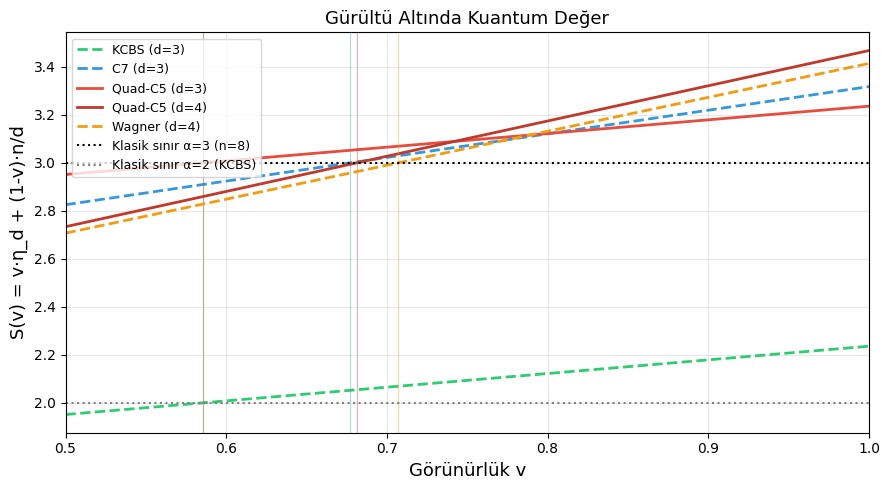

✓ data/noise_robustness.png kaydedildi


In [6]:
import matplotlib.pyplot as plt
import numpy as np

v_range = np.linspace(0.5, 1.0, 500)

def noisy_val(v, eta_d, n, d):
    return v * eta_d + (1-v) * n/d

configs = [
    ('KCBS (d=3)',     2.23607, 5, 3, 2, '#2ecc71',  '--'),
    ('C7 (d=3)',       3.31767, 7, 3, 3, '#3498db',  '--'),
    ('Quad-C5 (d=3)',  3.23607, 8, 3, 3, '#e74c3c',  '-'),
    ('Quad-C5 (d=4)',  3.46784, 8, 4, 3, '#c0392b',  '-'),
    ('Wagner (d=4)',   3.41421, 8, 4, 3, '#f39c12',  '--'),
]

fig, ax = plt.subplots(figsize=(9, 5))

for name, eta_d, n, d, alpha, color, ls in configs:
    vals = noisy_val(v_range, eta_d, n, d)
    ax.plot(v_range, vals, color=color, ls=ls, lw=2, label=name)
    vs = critical_visibility(alpha, eta_d, n, d)
    ax.axvline(vs, color=color, lw=0.8, alpha=0.4)

ax.axhline(3, color='black', lw=1.5, ls=':', label='Klasik sınır α=3 (n=8)')
ax.axhline(2, color='gray',  lw=1.5, ls=':', label='Klasik sınır α=2 (KCBS)')

ax.set_xlabel('Görünürlük v', fontsize=13)
ax.set_ylabel('S(v) = v·η_d + (1-v)·n/d', fontsize=13)
ax.set_title('Gürültü Altında Kuantum Değer', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0.5, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/noise_robustness.png', dpi=150)
plt.show()
print('✓ data/noise_robustness.png kaydedildi')